# Part 2: RFM Segmentation

## Business Objective

Customer segmentation helps identify high-value and at-risk customers based on their purchasing behavior.

RFM stands for:

- Recency (How recently a customer purchased)
- Frequency (How often a customer purchases)
- Monetary (How much a customer spends)

The objective is to classify customers into meaningful segments and recommend targeted business actions.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
rfm = pd.read_csv(
"/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Data/rfm_modeling_snapshot.csv"
)

rfm.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [4]:
print("Shape:", rfm.shape)

rfm.info()

Shape: (2400, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   flo

In [5]:
rfm.describe()

,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,87.375833,1.594583,1179.763196,0.061505,0.245094,3.847092,1.375417,0.229167,0.138819,5.093079,328.107917,5.460000,23.021667,1.560833,0.839167,0.672917,2.645833,0.649583,17.652500,0.469583
std,80.137473,1.184964,1035.900649,0.203092,0.139805,0.923442,0.896650,0.471779,0.343293,11.845798,179.604044,4.400167,19.818043,1.644919,0.996015,0.867225,2.763346,0.951579,15.905806,0.499178
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,1.000000,449.270000,0.000000,0.160000,3.500000,1.000000,0.000000,0.000000,0.000000,175.000000,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,66.000000,1.000000,911.875000,0.000000,0.260000,4.000000,1.000000,0.000000,0.000000,0.000000,330.000000,5.000000,18.000000,1.000000,1.000000,0.000000,2.000000,0.000000,14.000000,0.000000
75%,129.000000,2.000000,1681.510000,0.000000,0.340000,4.500000,2.000000,0.000000,0.000000,0.000000,480.250000,8.000000,34.000000,2.000000,1.000000,1.000000,5.000000,1.000000,27.000000,1.000000
max,562.000000,8.000000,6982.410000,1.000000,0.700000,5.000000,5.000000,3.000000,1.000000,73.800000,638.000000,25.000000,119.000000,12.000000,6.000000,7.000000,13.000000,6.000000,60.000000,1.000000


In [6]:
rfm['R_Score'] = pd.qcut(
    rfm['recency_days'],
    q=4,
    labels=[4,3,2,1]
)

In [7]:
rfm[['recency_days','R_Score']].head()

,recency_days,R_Score
0,107,2
1,40,3
2,171,1
3,131,1
4,38,3


In [8]:
rfm['F_Score'] = pd.qcut(
    rfm['frequency_180d'].rank(method='first'),
    q=4,
    labels=[1,2,3,4]
)

In [9]:
rfm[['frequency_180d','F_Score']].head()

,frequency_180d,F_Score
0,1,1
1,1,1
2,1,1
3,1,1
4,3,4


In [10]:
rfm['M_Score'] = pd.qcut(
    rfm['monetary_180d'],
    q=4,
    labels=[1,2,3,4]
)

In [11]:
rfm[['monetary_180d','M_Score']].head()

,monetary_180d,M_Score
0,362.73,1
1,581.00,2
2,649.98,2
3,1604.04,3
4,1781.90,4


In [12]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

In [13]:
rfm[['customer_id',
     'R_Score',
     'F_Score',
     'M_Score',
     'RFM_Score']].head()

,customer_id,R_Score,F_Score,M_Score,RFM_Score
0,CUST00001,2,1,1,211
1,CUST00002,3,1,2,312
2,CUST00003,1,1,2,112
3,CUST00004,1,1,3,113
4,CUST00005,3,4,4,344


In [14]:
def segment_customer(row):

    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    elif r >= 3 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

In [15]:
rfm['Customer_Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

In [16]:
rfm['Customer_Segment'].value_counts()

,count
Customer_Segment,
Lost Customers,762
Loyal Customers,623
Potential Loyalists,438
At Risk,427
Champions,150


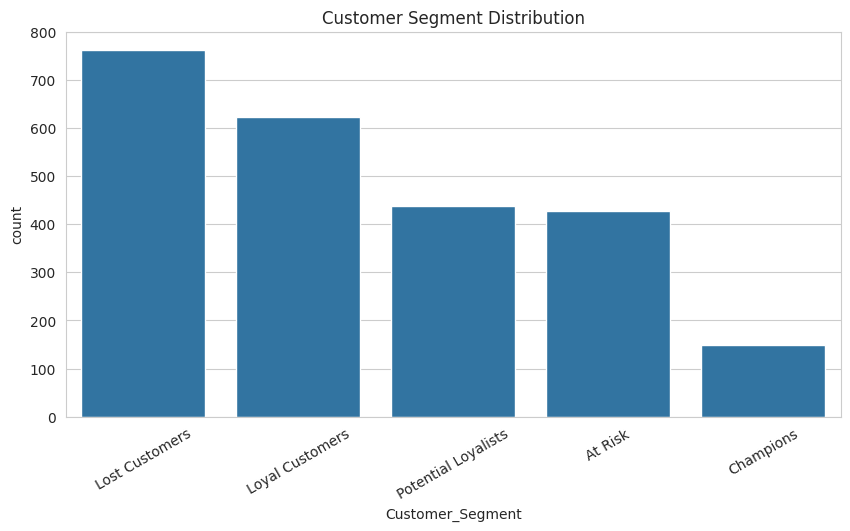

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    x='Customer_Segment',
    order=rfm['Customer_Segment'].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xticks(rotation=30)

plt.show()

In [18]:
segment_summary = rfm.groupby(
    'Customer_Segment'
)[[
    'recency_days',
    'frequency_180d',
    'monetary_180d',
    'churn_next_60d'
]].mean()

segment_summary.round(2)

,recency_days,frequency_180d,monetary_180d,churn_next_60d
Customer_Segment,,,,
At Risk,106.45,2.15,1605.82,0.56
Champions,10.92,3.78,2940.23,0.03
Lost Customers,171.27,0.60,448.77,0.84
Loyal Customers,31.93,2.32,1652.47,0.20
Potential Loyalists,27.88,1.00,760.86,0.27


In [19]:
segment_summary.round(2)

,recency_days,frequency_180d,monetary_180d,churn_next_60d
Customer_Segment,,,,
At Risk,106.45,2.15,1605.82,0.56
Champions,10.92,3.78,2940.23,0.03
Lost Customers,171.27,0.60,448.77,0.84
Loyal Customers,31.93,2.32,1652.47,0.20
Potential Loyalists,27.88,1.00,760.86,0.27


## Segment Analysis and Business Insights

### Champions
- 150 customers
- Highest spending customers
- Most recent purchasers
- Lowest churn rate (3%)

Business Action:
- VIP rewards
- Exclusive product launches
- Referral programs

---

### Loyal Customers
- 623 customers
- Strong repeat purchasing behavior
- Moderate spending levels
- Low churn risk (20%)

Business Action:
- Loyalty programs
- Personalized recommendations
- Upsell opportunities

---

### Potential Loyalists
- 438 customers
- Recently active but low purchase frequency
- Moderate churn risk (27%)

Business Action:
- First-to-second purchase campaigns
- Personalized discounts
- Product recommendations

---

### At Risk Customers
- 427 customers
- Previously valuable customers
- High churn risk (56%)

Business Action:
- Win-back campaigns
- Personalized emails
- Special retention offers

---

### Lost Customers
- 762 customers
- Lowest spending and engagement
- Extremely high churn risk (84%)

Business Action:
- Re-engagement campaigns
- Exit surveys
- Low-cost marketing interventions

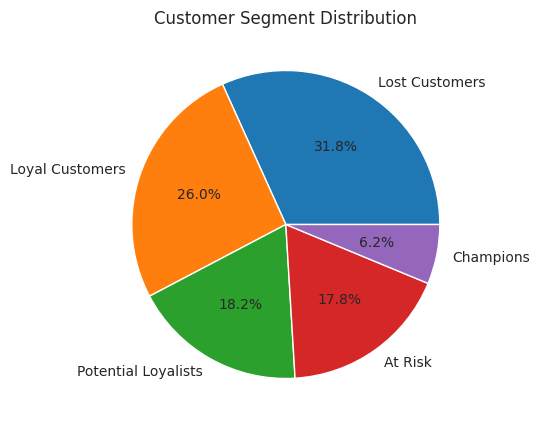

In [20]:
plt.figure(figsize=(8,5))

segment_counts = rfm['Customer_Segment'].value_counts()

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Customer Segment Distribution")

plt.show()

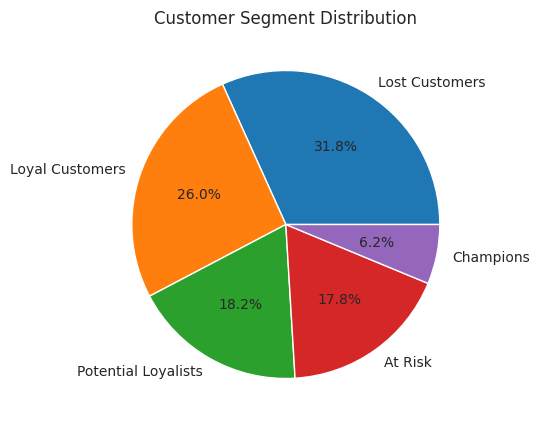

In [21]:
import os
viz_path = "/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Part2_RFM_Segmentation/"

# Create the directory if it doesn't exist
os.makedirs(viz_path, exist_ok=True)

plt.figure(figsize=(8,5))

segment_counts = rfm['Customer_Segment'].value_counts()

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Customer Segment Distribution")

plt.savefig(f"{viz_path}/segment_distribution_pie.png",
            bbox_inches='tight')

plt.show()

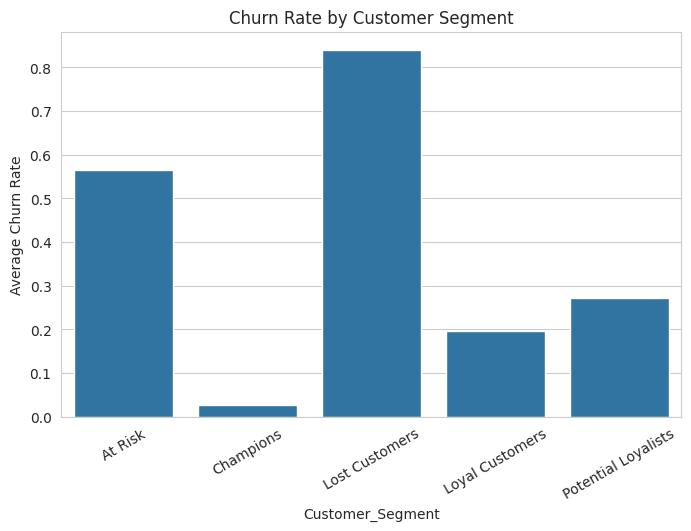

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_summary.index,
    y=segment_summary['churn_next_60d']
)

plt.xticks(rotation=30)

plt.ylabel("Average Churn Rate")

plt.title("Churn Rate by Customer Segment")

plt.show()

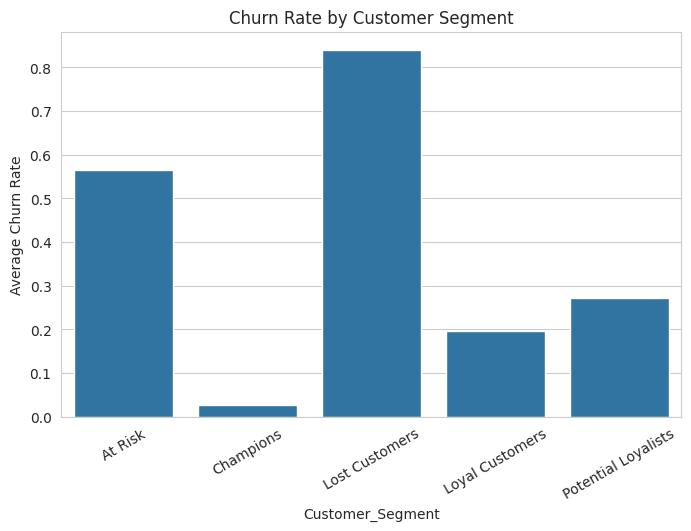

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_summary.index,
    y=segment_summary['churn_next_60d']
)

plt.xticks(rotation=30)

plt.ylabel("Average Churn Rate")

plt.title("Churn Rate by Customer Segment")

plt.savefig(f"{viz_path}/churn_rate_by_segment.png",
            bbox_inches='tight')

plt.show()

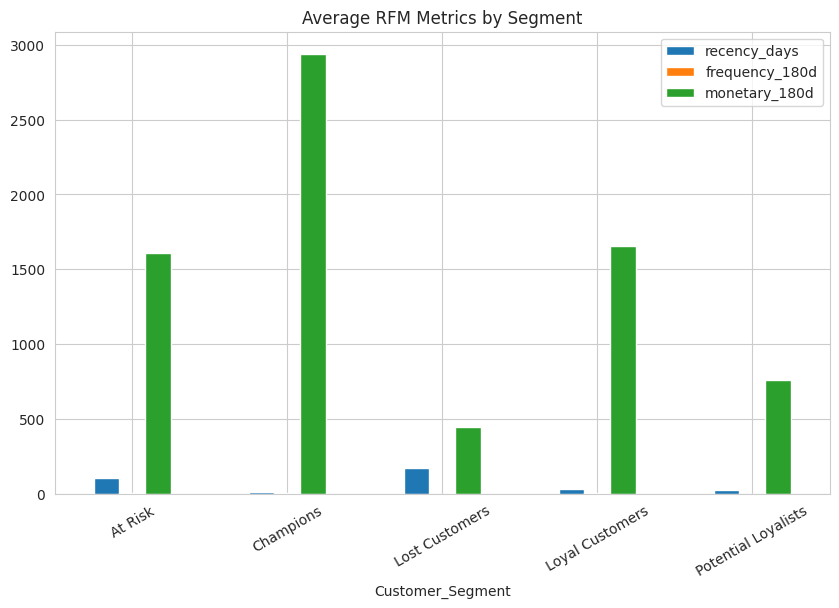

In [24]:
segment_summary[['recency_days',
                 'frequency_180d',
                 'monetary_180d']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average RFM Metrics by Segment")

plt.xticks(rotation=30)

plt.show()

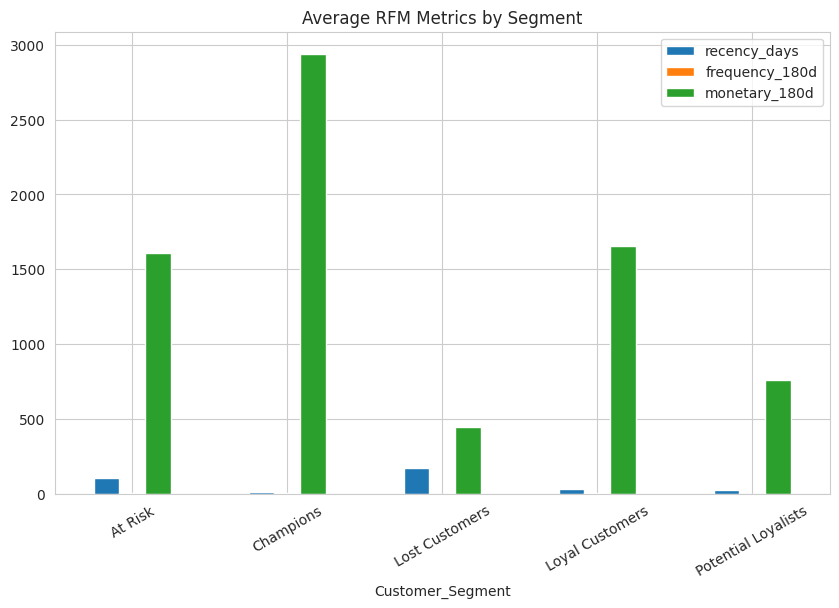

In [25]:
segment_summary[['recency_days',
                 'frequency_180d',
                 'monetary_180d']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average RFM Metrics by Segment")

plt.xticks(rotation=30)

plt.savefig(f"{viz_path}/rfm_segment_metrics.png",
            bbox_inches='tight')

plt.show()

# Conclusion

RFM segmentation successfully classified customers into five actionable business segments.

Key findings:

1. Champions represent the most valuable customer base with the highest spending and lowest churn.

2. Loyal Customers contribute significantly to revenue and should be retained through loyalty programs.

3. Potential Loyalists represent an opportunity for growth through targeted marketing.

4. At Risk customers require immediate retention efforts.

5. Lost Customers exhibit extremely high churn probability and should be targeted through reactivation campaigns.

The segmentation framework provides actionable insights for customer retention and revenue optimization strategies.

In [26]:
rfm.to_csv(
"/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Data/rfm_segmented.csv",
index=False
)

In [28]:
rfm.to_csv("customer_segments.csv", index=False)

print("customer_segments.csv saved successfully")

customer_segments.csv saved successfully


In [29]:
import os
os.listdir()

['.config', 'customer_segments.csv', 'drive', 'sample_data']

In [30]:
from google.colab import files
files.download("customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>